In [2]:
!pip3 install -U ray

import pandas as pd
import numpy as np
import ray

ray.init(ignore_reinit_error=True)

2026-05-09 15:53:44,867	INFO worker.py:2012 -- Started a local Ray instance.
/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


Python version:,3.12.13
Ray version:,2.55.1


In [3]:
columns_to_keep = [
    'appid', 'name', 'categories', 'genres', 'steamspy_tags',
    'positive_ratings', 'negative_ratings', 'average_playtime', 'price'
]

df = pd.read_csv('steam.csv', usecols=columns_to_keep)

In [4]:

df.dropna(subset=['genres'], inplace=True)

df['Rating_Ratio'] = df['positive_ratings'] / (df['positive_ratings'] + df['negative_ratings'])

In [5]:

df['positive_ratings'] = df['positive_ratings'].astype('int32')
df['negative_ratings'] = df['negative_ratings'].astype('int32')
df['price'] = df['price'].astype('float32')
df['average_playtime'] = df['average_playtime'].astype('int32')
df['Rating_Ratio'] = df['Rating_Ratio'].astype('float32')

In [6]:
upper_bound = df['average_playtime'].quantile(0.95)


df['average_playtime'] = np.where(
    df['average_playtime'] > upper_bound,
    upper_bound,
    df['average_playtime']
)

In [7]:

print("Dataset Dimensionality:", df.shape)

print("\nDescriptive Statistics:")
print(df.describe())

Dataset Dimensionality: (27075, 10)

Descriptive Statistics:
              appid  positive_ratings  negative_ratings  average_playtime  \
count  2.707500e+04      2.707500e+04      27075.000000      27075.000000   
mean   5.962035e+05      1.000559e+03        211.027147         49.521145   
std    2.508942e+05      1.898872e+04       4284.938531        114.745948   
min    1.000000e+01      0.000000e+00          0.000000          0.000000   
25%    4.012300e+05      6.000000e+00          2.000000          0.000000   
50%    5.990700e+05      2.400000e+01          9.000000          0.000000   
75%    7.987600e+05      1.260000e+02         42.000000          0.000000   
max    1.069460e+06      2.644404e+06     487076.000000        413.000000   

              price  Rating_Ratio  
count  27075.000000  27075.000000  
mean       6.078193      0.714478  
std        7.875195      0.233598  
min        0.000000      0.000000  
25%        1.690000      0.583333  
50%        3.990000      0.76

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

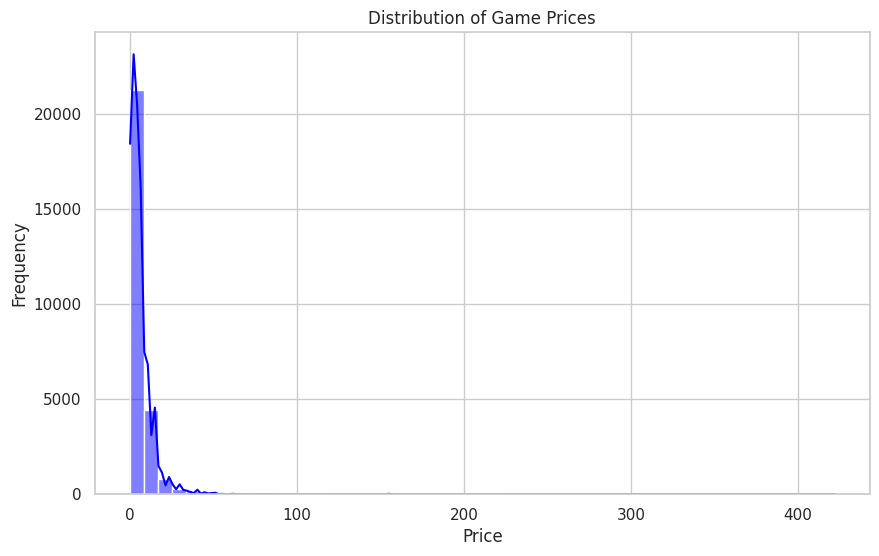

In [9]:
plt.figure(figsize=(10, 6))

sns.histplot(df['price'], bins=50, kde=True, color='blue')
plt.title('Distribution of Game Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.show()

/tmp/ipykernel_11318/1747085628.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')


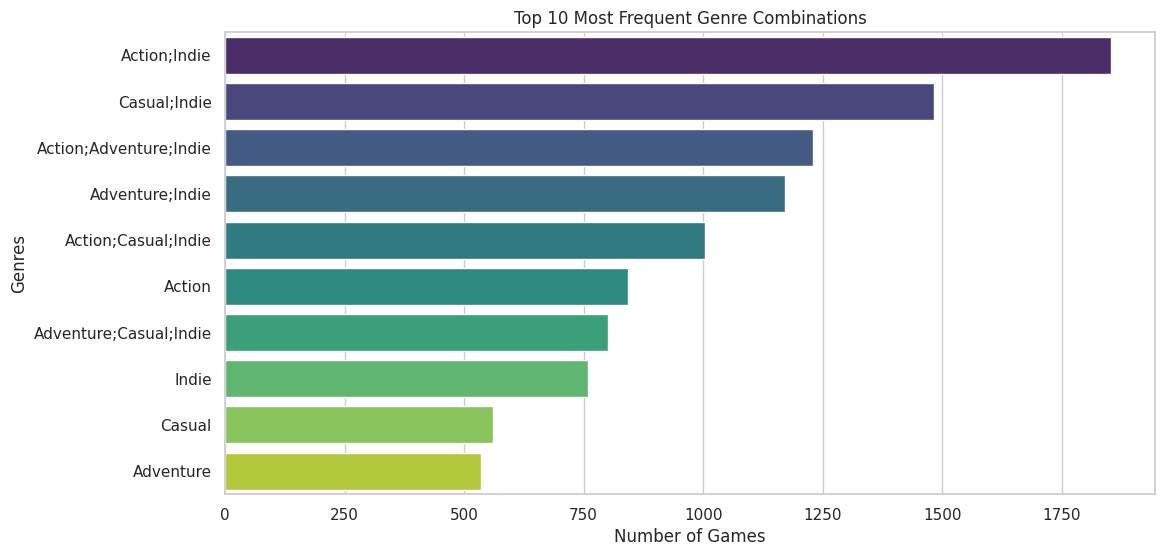

In [10]:
plt.figure(figsize=(12, 6))

top_genres = df['genres'].value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index, palette='viridis')
plt.title('Top 10 Most Frequent Genre Combinations')
plt.xlabel('Number of Games')
plt.ylabel('Genres')
plt.show()

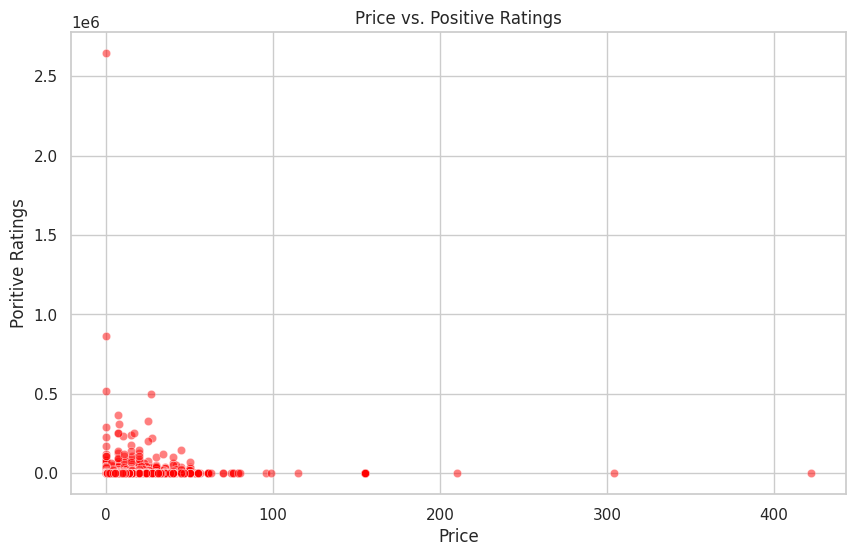

In [11]:
plt.figure(figsize=(10, 6))

sns.scatterplot(x='price', y='positive_ratings', data=df, alpha=0.5, color='red')
plt.title('Price vs. Positive Ratings')
plt.xlabel('Price')
plt.ylabel('Poritive Ratings')
plt.show()

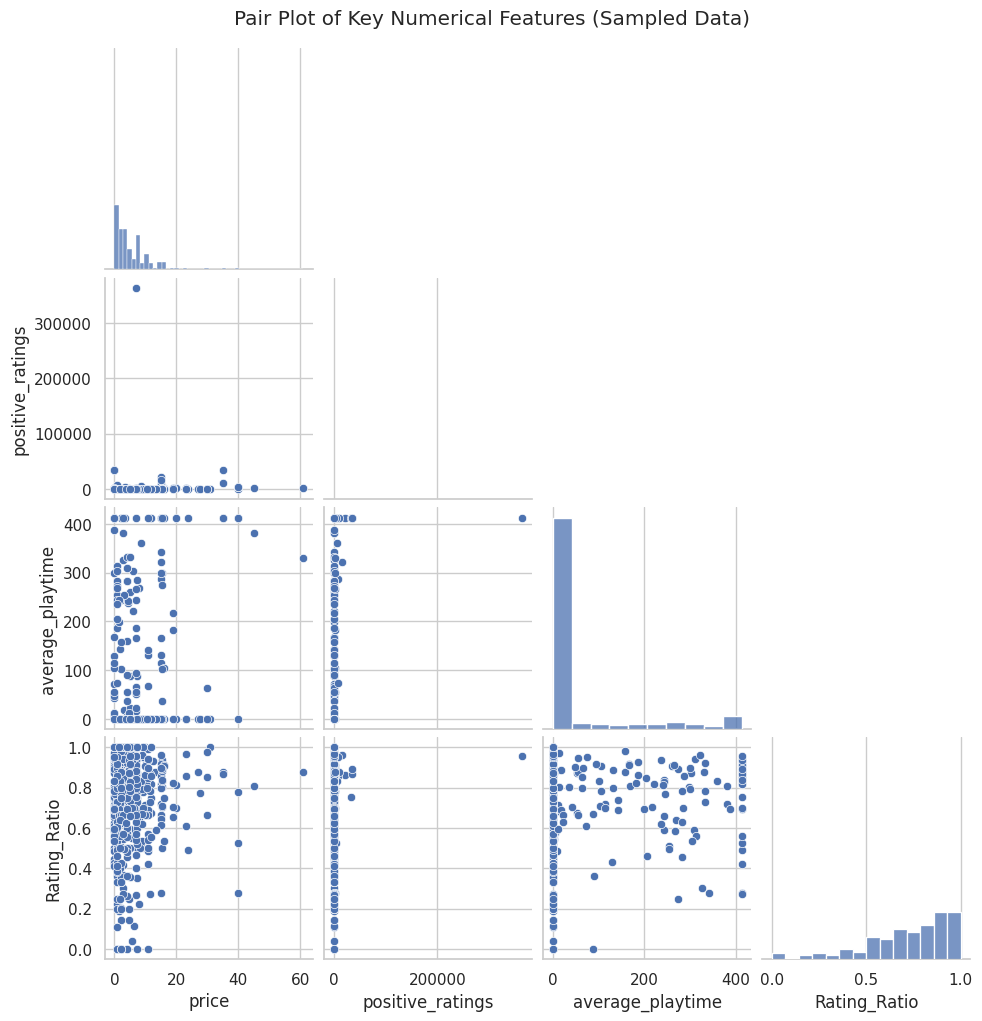

In [12]:
sampled_df = df.sample(n=500, random_state=42)


columns_for_pairplot = ['price', 'positive_ratings', 'average_playtime', 'Rating_Ratio']


sns.pairplot(sampled_df[columns_for_pairplot], corner=True)
plt.suptitle('Pair Plot of Key Numerical Features (Sampled Data)', y=1.02)
plt.show()

In [13]:

popular_games = df


popular_games.reset_index(drop=True, inplace=True)

print(f"Reduced dataset from {len(df)} to {len(popular_games)} games.")

Reduced dataset from 27075 to 27075 games.


In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer


popular_games['combined_features'] = popular_games['genres'].fillna('') + popular_games['steamspy_tags'].fillna('')


tfv = TfidfVectorizer(stop_words='english')


tfv_matrix = tfv.fit_transform(popular_games['combined_features'].tolist())

In [15]:
from sklearn.metrics.pairwise import linear_kernel

sig = linear_kernel(tfv_matrix, tfv_matrix)

In [16]:

indices = pd.Series(popular_games.index, index=popular_games['name']).drop_duplicates()

def get_recommendations(title, sig=sig):

    if title not in indices:
        return "Game not found in popular dataset. Try another."


    idx = indices[title]


    sig_scores = list(enumerate(sig[idx]))


    sig_scores = sorted(sig_scores, key=lambda x: x[1], reverse=True)

    sig_scores = sig_scores[1:11]

    game_indices = [i[0] for i in sig_scores]


    return popular_games['name'].iloc[game_indices]

print("Recommendations for 'Dragon Ball Xenoverse':")
print(get_recommendations('Left 4 Dead 2'))

Recommendations for 'Dragon Ball Xenoverse':
21                                 Left 4 Dead 2
1592              Sniper Elite: Nazi Zombie Army
3254                         Zombie Army Trilogy
1653                             Killing Floor 2
1236                               Serious Sam 2
251                   Call of Duty: World at War
7242                                   Earthfall
2318            Dead Rising 3 Apocalypse Edition
6103     Dead Island: Riptide Definitive Edition
11515                              Dead Rising 4
Name: name, dtype: object


In [ ]:
idx = indices['Left 4 Dead 2']
top10 = sorted(enumerate(sig[idx]), key=lambda x: x[1], reverse=True)[1:11]
avg_sim = sum(s for _, s in top10) / 10
print(f"Average recommendation similarity score: {avg_sim:.4f}")

K-Means Silhouette Score: 0.4471


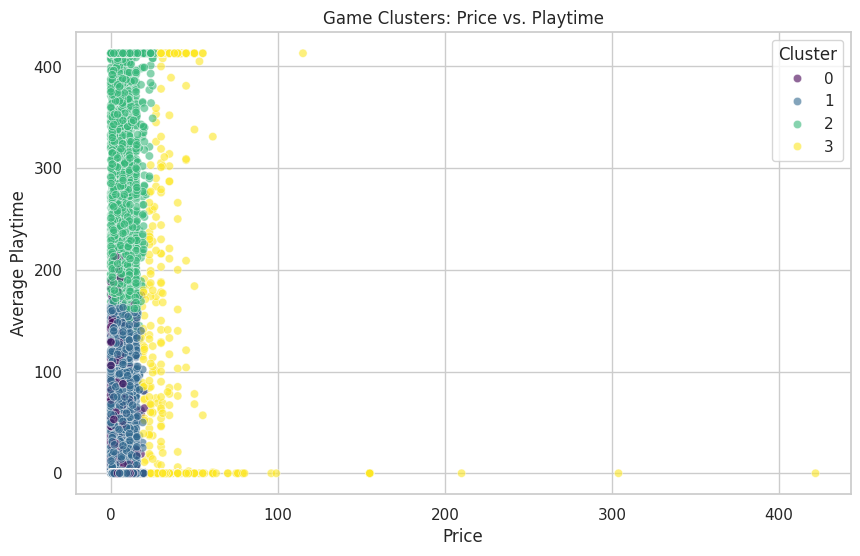


Sample games from Cluster 0:
                                   name  price  Rating_Ratio
38  Iron Warriors: T - 72 Tank Command    3.99      0.573222
54   QUAKE II Mission Pack: Ground Zero   2.49      0.620690
62           Gumboy - Crazy Adventures™   0.00      0.530612
63                          Alpha Prime   2.99      0.538394
87                       Genesis Rising   4.49      0.241935


In [17]:
# # Phase 2: K-Means Clustering & Evaluation

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns


features_for_clustering = ['price', 'average_playtime', 'Rating_Ratio']
X = popular_games[features_for_clustering].copy()


X.fillna(X.mean(), inplace=True)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
popular_games['Cluster'] = kmeans.fit_predict(X_scaled)


sil_score = silhouette_score(X_scaled, popular_games['Cluster'])
print(f"K-Means Silhouette Score: {sil_score:.4f}")


plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=popular_games['price'],
    y=popular_games['average_playtime'],
    hue=popular_games['Cluster'],
    palette='viridis',
    alpha=0.6
)
plt.title('Game Clusters: Price vs. Playtime')
plt.xlabel('Price')
plt.ylabel('Average Playtime')
plt.show()


print("\nSample games from Cluster 0:")
print(popular_games[popular_games['Cluster'] == 0][['name', 'price', 'Rating_Ratio']].head())

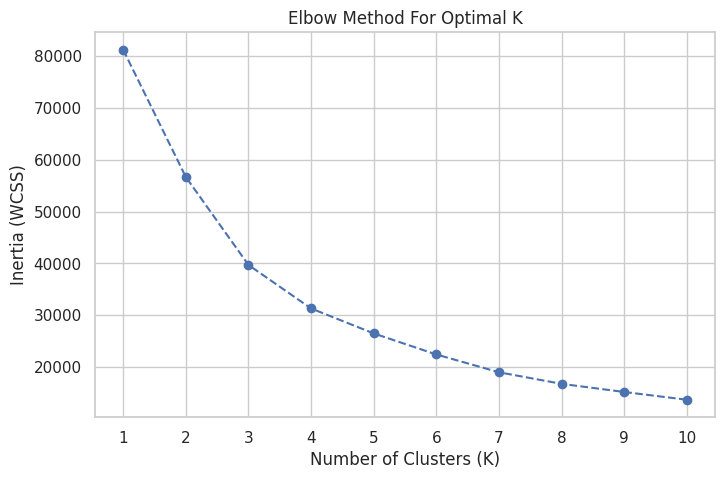

In [18]:
# Metric 2: Within-Cluster Sum of Squares (Inertia)
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', linestyle='--', color='b')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(K_range)
plt.grid(True)
plt.show()


/tmp/ipykernel_11318/4084214568.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=popular_games, x='Cluster', palette='Set2')


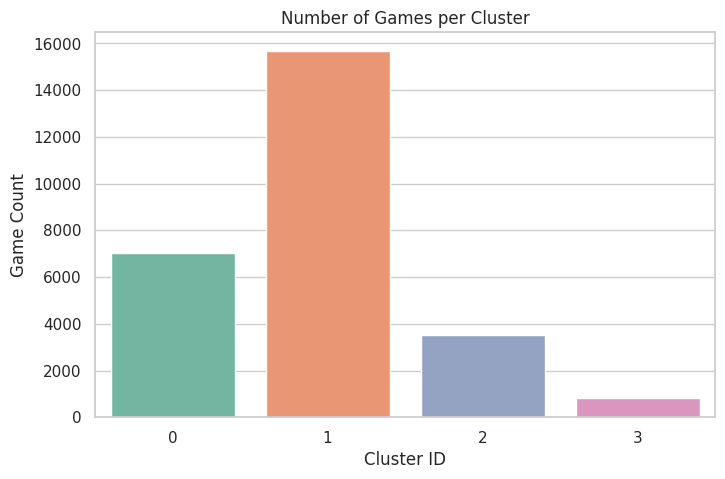

In [19]:
# Metric 3: Cluster Population Sizes
plt.figure(figsize=(8, 5))
sns.countplot(data=popular_games, x='Cluster', palette='Set2')
plt.title('Number of Games per Cluster')
plt.xlabel('Cluster ID')
plt.ylabel('Game Count')
plt.show()

/tmp/ipykernel_11318/1172282821.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='price', data=popular_games, palette='Set2')


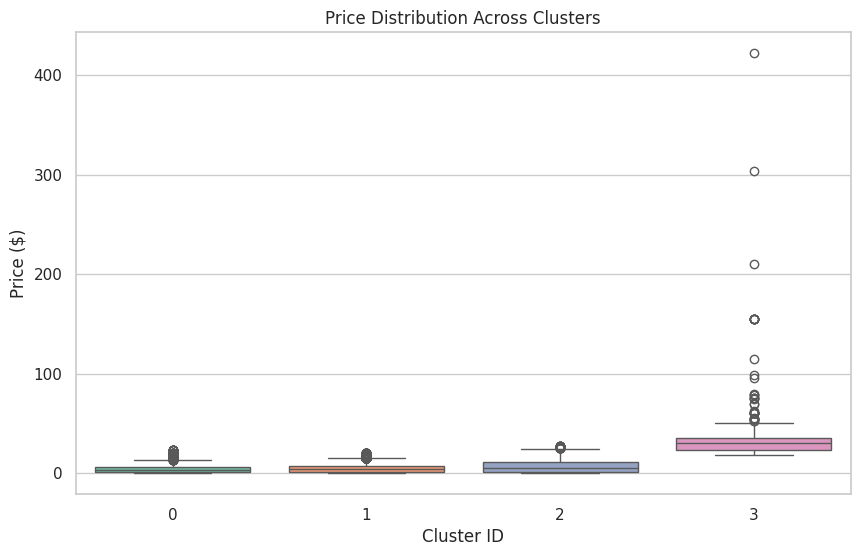

/tmp/ipykernel_11318/1172282821.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster', y='average_playtime', data=popular_games, palette='Set2')


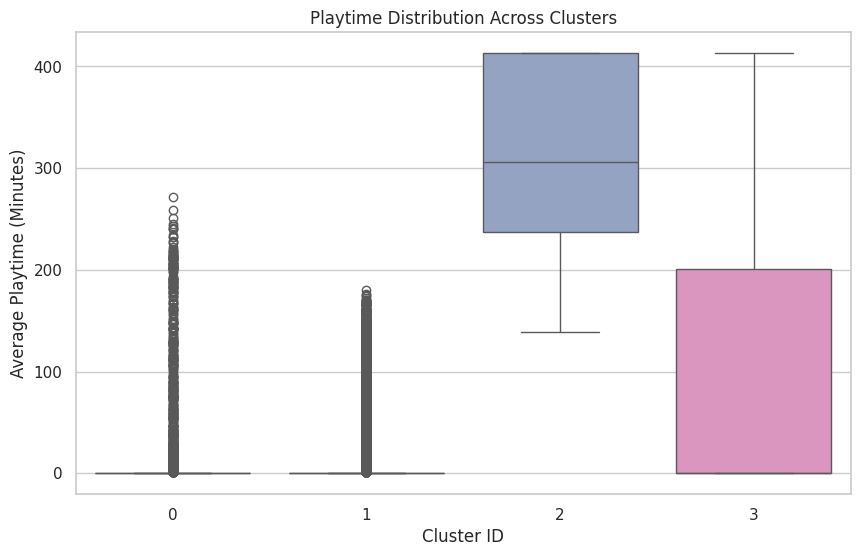

In [20]:
# Graph 4: Profiling the Clusters by Price
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='price', data=popular_games, palette='Set2')
plt.title('Price Distribution Across Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('Price ($)')
plt.show()

# Graph 5: Profiling the Clusters by Playtime
plt.figure(figsize=(10, 6))
sns.boxplot(x='Cluster', y='average_playtime', data=popular_games, palette='Set2')
plt.title('Playtime Distribution Across Clusters')
plt.xlabel('Cluster ID')
plt.ylabel('Average Playtime (Minutes)')
plt.show()

In [21]:
# Aggregate the mathematical means for each cluster
cluster_analysis = popular_games.groupby('Cluster')[['price', 'average_playtime', 'Rating_Ratio']].mean()
print("Cluster Profiles (Mean Values):")
print(cluster_analysis)

Cluster Profiles (Mean Values):
             price  average_playtime  Rating_Ratio
Cluster                                           
0         4.218527          6.142148      0.409411
1         5.267265          6.574678      0.842489
2         6.913335        315.095211      0.747494
3        33.876507        107.951456      0.745540
